# Step 1: Importing the necessary libraries

In [47]:
#Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Loading the dataset

In [48]:
df=pd.read_csv(r"Breast Cancer METABRIC.csv")

## Step 3: Data Preprocessing & EDA

In [49]:
df.shape

(2509, 34)

In [50]:
df.head(5)

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,...,Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,MB-0000,75.65,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,No,claudin-low,1.0,Positve,...,Living,Negative,Yes,138.65,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living
1,MB-0002,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1.0,Positve,...,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living
2,MB-0005,48.87,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,No,151.28,Recurred,Female,NaN,15.0,2.0,Died of Disease
3,MB-0006,47.68,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,Yes,LumB,1.0,Positve,...,Living,Positive,Yes,162.76,Not Recurred,Female,NaN,25.0,2.0,Living
4,MB-0008,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2509 entries, 0 to 2508
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Patient ID                      2509 non-null   object 
 1   Age at Diagnosis                2498 non-null   float64
 2   Type of Breast Surgery          1955 non-null   object 
 3   Cancer Type                     2509 non-null   object 
 4   Cancer Type Detailed            2509 non-null   object 
 5   Cellularity                     1917 non-null   object 
 6   Chemotherapy                    1980 non-null   object 
 7   Pam50 + Claudin-low subtype     1980 non-null   object 
 8   Cohort                          2498 non-null   float64
 9   ER status measured by IHC       2426 non-null   object 
 10  ER Status                       2469 non-null   object 
 11  Neoplasm Histologic Grade       2388 non-null   float64
 12  HER2 status measured by SNP6    19

In [52]:
df.isna().sum()

Patient ID                          0
Age at Diagnosis                   11
Type of Breast Surgery            554
Cancer Type                         0
Cancer Type Detailed                0
Cellularity                       592
Chemotherapy                      529
Pam50 + Claudin-low subtype       529
Cohort                             11
ER status measured by IHC          83
ER Status                          40
Neoplasm Histologic Grade         121
HER2 status measured by SNP6      529
HER2 Status                       529
Tumor Other Histologic Subtype    135
Hormone Therapy                   529
Inferred Menopausal State         529
Integrative Cluster               529
Primary Tumor Laterality          639
Lymph nodes examined positive     266
Mutation Count                    152
Nottingham prognostic index       222
Oncotree Code                       0
Overall Survival (Months)         528
Overall Survival Status           528
PR Status                         529
Radio Therap

In [53]:
## unique identifier it does't have any pattern and not used for modeling
df.drop(columns=["Patient ID"], inplace=True)

In [54]:
## Seperating the columns types for imputeing
num_cols = df.select_dtypes(include=["int64","float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns


In [55]:
## imputeing the numerical missing values 
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")
df[num_cols] = num_imputer.fit_transform(df[num_cols])


In [56]:
## imputeing categorical missing values 
for col in cat_cols:
    df[col]=df[col].fillna(df[col].mode()[0])  

In [57]:
df.isna().sum()

Age at Diagnosis                  0
Type of Breast Surgery            0
Cancer Type                       0
Cancer Type Detailed              0
Cellularity                       0
Chemotherapy                      0
Pam50 + Claudin-low subtype       0
Cohort                            0
ER status measured by IHC         0
ER Status                         0
Neoplasm Histologic Grade         0
HER2 status measured by SNP6      0
HER2 Status                       0
Tumor Other Histologic Subtype    0
Hormone Therapy                   0
Inferred Menopausal State         0
Integrative Cluster               0
Primary Tumor Laterality          0
Lymph nodes examined positive     0
Mutation Count                    0
Nottingham prognostic index       0
Oncotree Code                     0
Overall Survival (Months)         0
Overall Survival Status           0
PR Status                         0
Radio Therapy                     0
Relapse Free Status (Months)      0
Relapse Free Status         

In [58]:
df.isna().sum().sum()  ## Now our dataset is clean

np.int64(0)

In [59]:
df["Patient's Vital Status"].value_counts()

Patient's Vital Status
Living                  1366
Died of Disease          646
Died of Other Causes     497
Name: count, dtype: int64

In [60]:
## Checking min months and max month
print(df["Overall Survival (Months)"].min())
print(df["Overall Survival (Months)"].max())

0.0
355.2


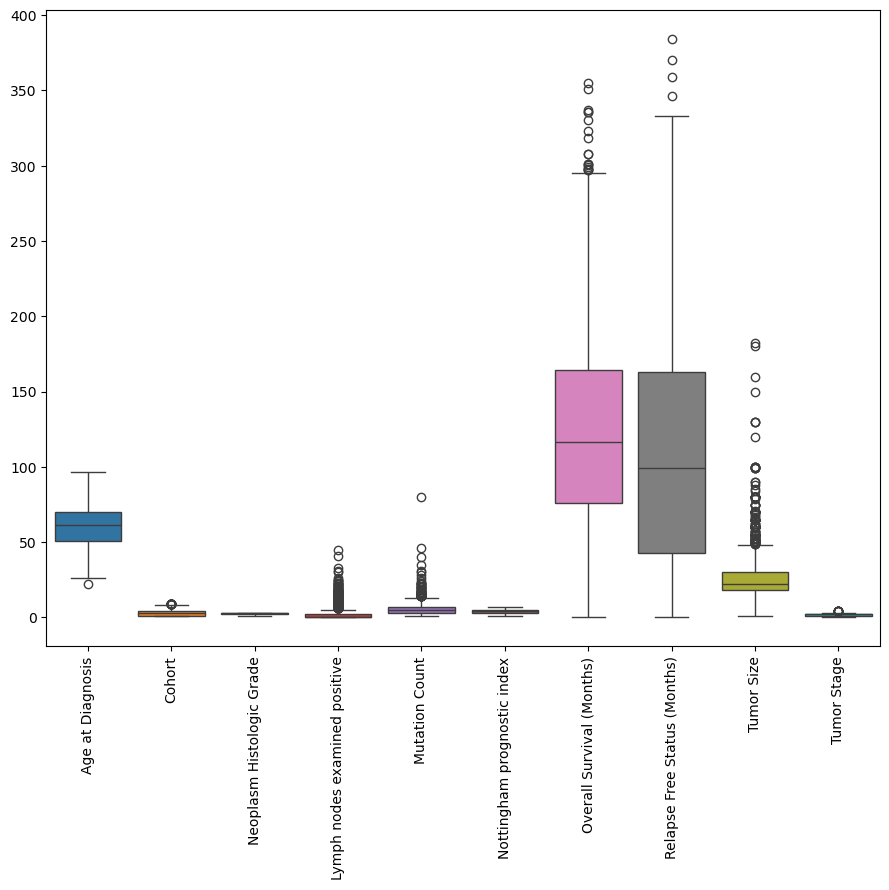

In [61]:
## checking the outerliers  using the box plot 
plt.figure(figsize=(9, 9))
sns.boxplot(data=df)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [62]:
# I used the IQR method to cap outliers, replacing extreme values beyond 1.5×IQR with boundary values to reduce their influence without removing observations.
## I used this method because In medical data Extreme values are often real, not errors
#Removing rows can lose important patients
#Capping reduces their influence without deleting data
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] > upper, upper,
              np.where(df[col] < lower, lower, df[col]))

In [63]:
## In the above below the lower layer we cap with lower value and above the upper value we cap with upper value
print(lower)
print(upper)

-0.5
3.5


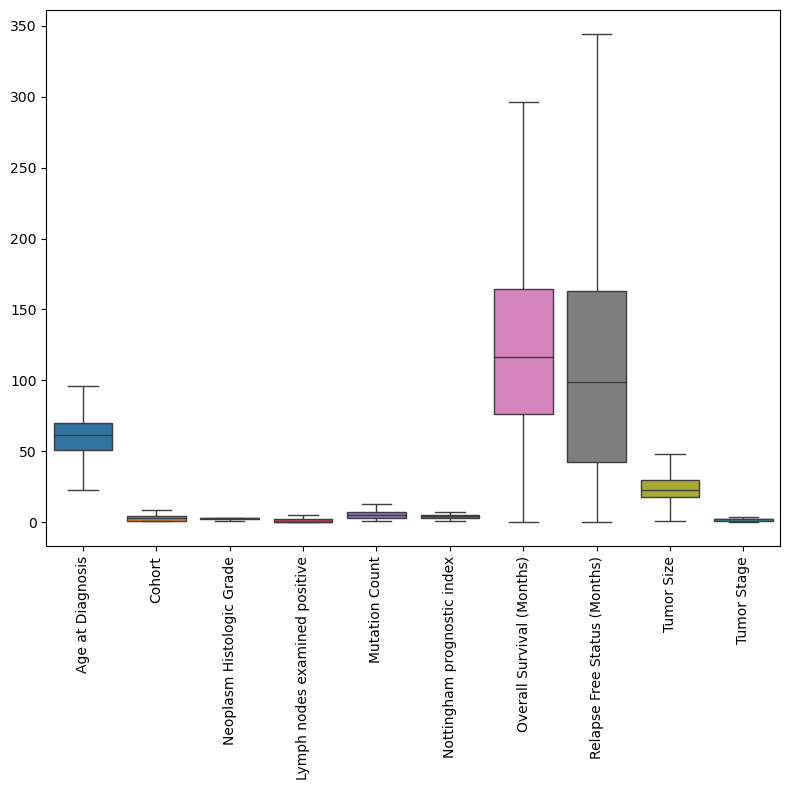

In [64]:
## again we checking outerlier useing the boxplot after capping the outerliers
plt.figure(figsize=(8,8))
sns.boxplot(data=df)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [65]:
## Here we creating a mortality_10yr column Target column
df["mortality_10yr"] = (
    (df["Overall Survival (Months)"] <= 120) &   ## takeing only survival of below and equal to the 120 months 
    (df["Patient's Vital Status"] != "Living")  ## died due to the desease
).astype(int)                                    ## True  True = True
                                                 ## False Fasle = False


In [66]:
df["mortality_10yr"].value_counts()

mortality_10yr
0    1749
1     760
Name: count, dtype: int64

In [67]:
# df.to_csv("clean_dataset.csv", index=False)

In [68]:
#Here I making a safe copy of our cleaned data_set
#we don’t want to break our ML dataset
#Survival analysis needs original columns
#Did this patient die or not handling This is called censoring handling.

df_survival = df.copy()


In [69]:
df_survival["Patient's Vital Status"].value_counts()

Patient's Vital Status
Living                  1366
Died of Disease          646
Died of Other Causes     497
Name: count, dtype: int64

In [70]:
## Here we creating a event column useing the patient's vital status with two class
df_survival["event"] = (df_survival["Patient's Vital Status"] != "Living").astype(int)


In [71]:
df_survival["event"].value_counts()

event
0    1366
1    1143
Name: count, dtype: int64

## Exploratory Data Analysis and Visulization

## Data Exploration

- To understand patterns & potentially form some hypothesis

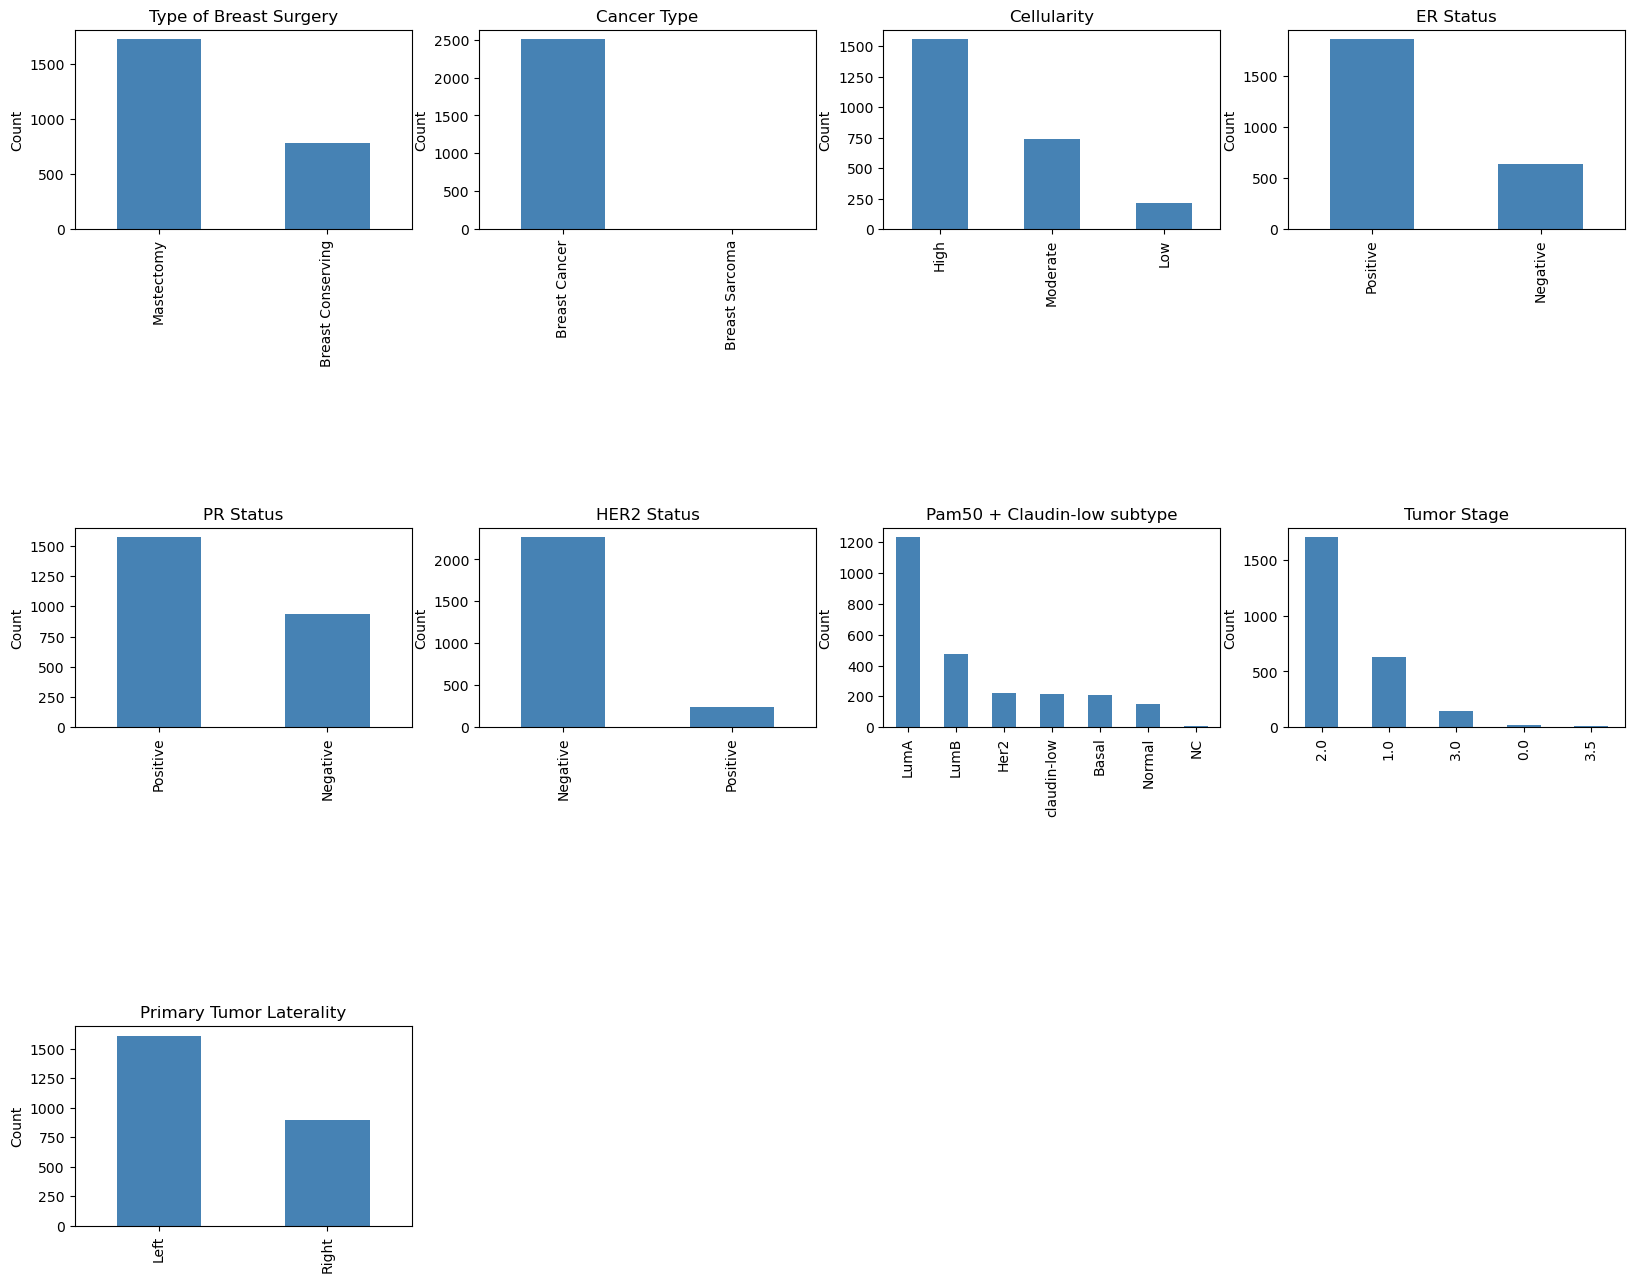

In [72]:
cat_cols = [
    "Type of Breast Surgery",
    "Cancer Type",
    # "Cancer Type Detailed",
    "Cellularity",
    "ER Status",
    "PR Status",
    "HER2 Status",
    "Pam50 + Claudin-low subtype",
    "Tumor Stage",
    "Primary Tumor Laterality"
]
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 22))
plt.subplots_adjust(hspace=1.5)

for i, col in enumerate(cat_cols):
    row, col_idx = divmod(i, 4)   
    ax = axes[row, col_idx]

    df[col].value_counts().plot(
        kind="bar",
        ax=ax,
        color="steelblue",
        rot=0
    )

    ax.tick_params(axis='x', rotation=90)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Count")


for j in range(len(cat_cols), 16):
    fig.delaxes(axes.flatten()[j])

plt.show()


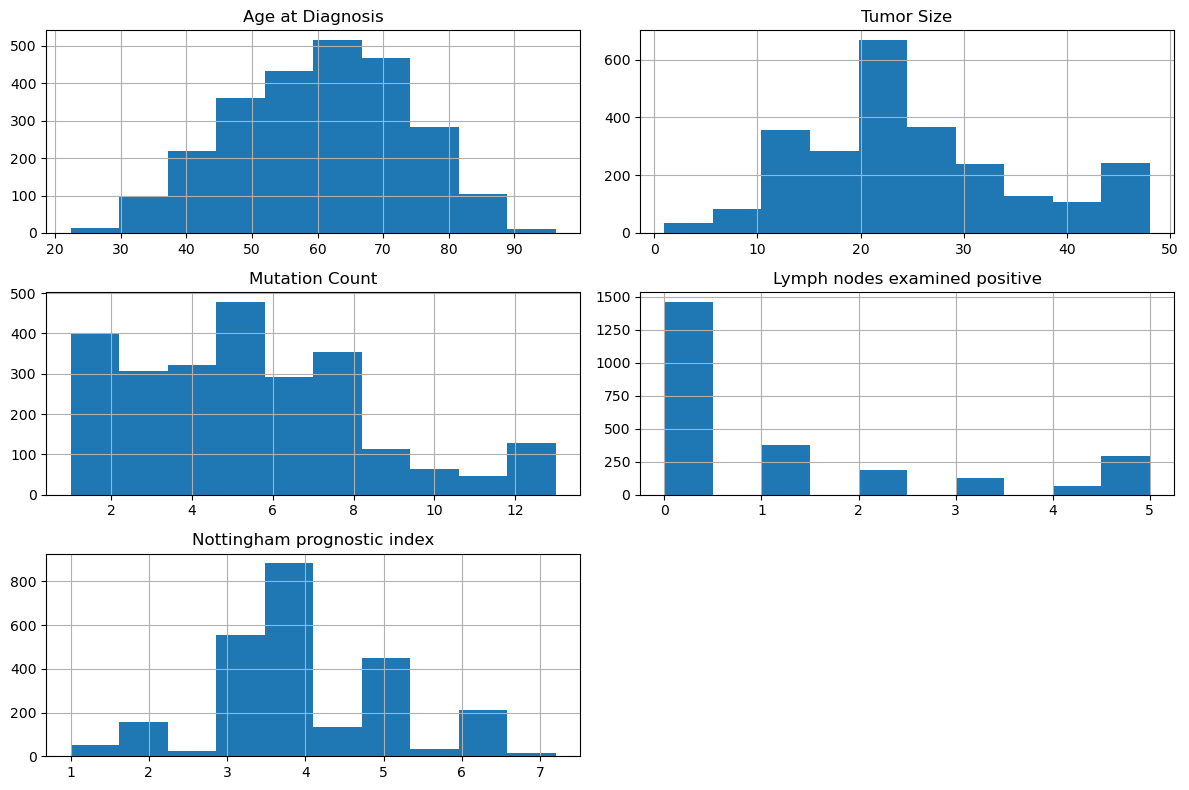

In [73]:
num_cols = [
    "Age at Diagnosis",
    "Tumor Size",
    "Mutation Count",
    "Lymph nodes examined positive",
    "Nottingham prognostic index"
]

df[num_cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show()


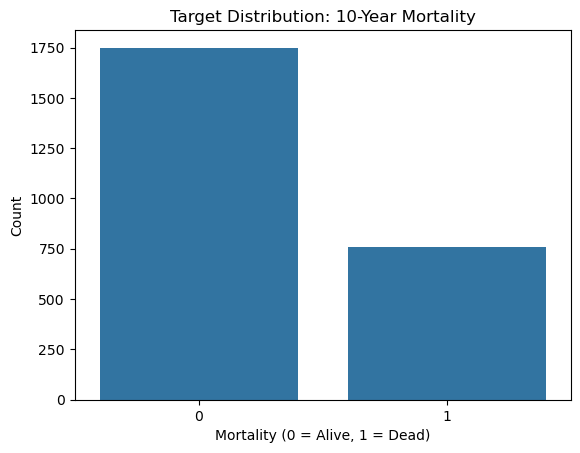

In [74]:
## Mortality_10yr Distribution
sns.countplot(x="mortality_10yr", data=df)
plt.title("Target Distribution: 10-Year Mortality")
plt.xlabel("Mortality (0 = Alive, 1 = Dead)")
plt.ylabel("Count")
plt.show()


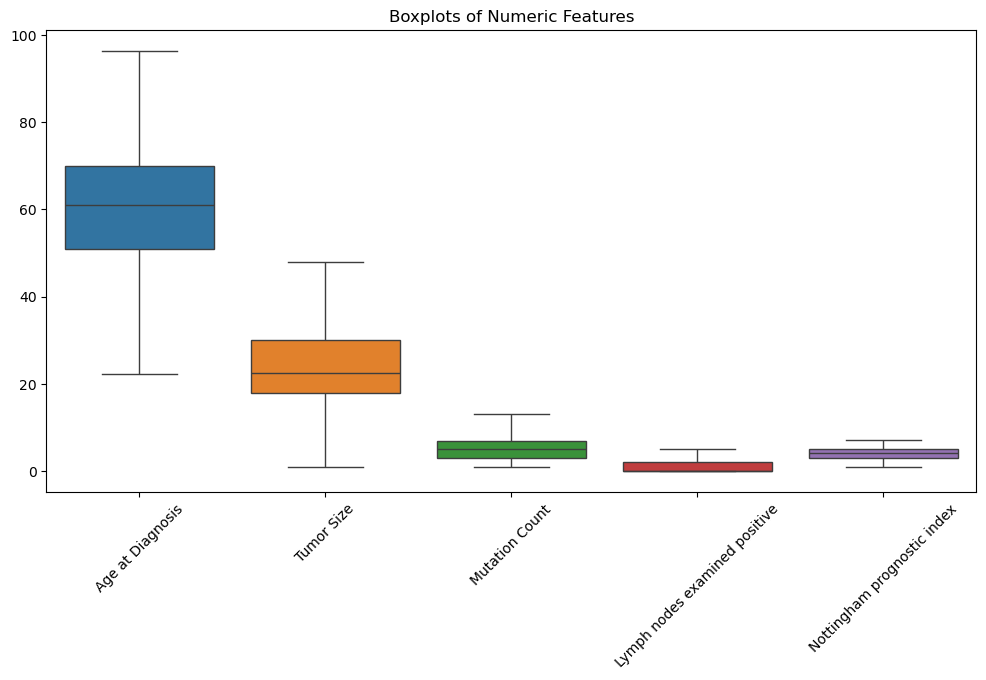

In [75]:
## To check the Outerliers
plt.figure(figsize=(12,6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=45)
plt.title("Boxplots of Numeric Features")
plt.show()


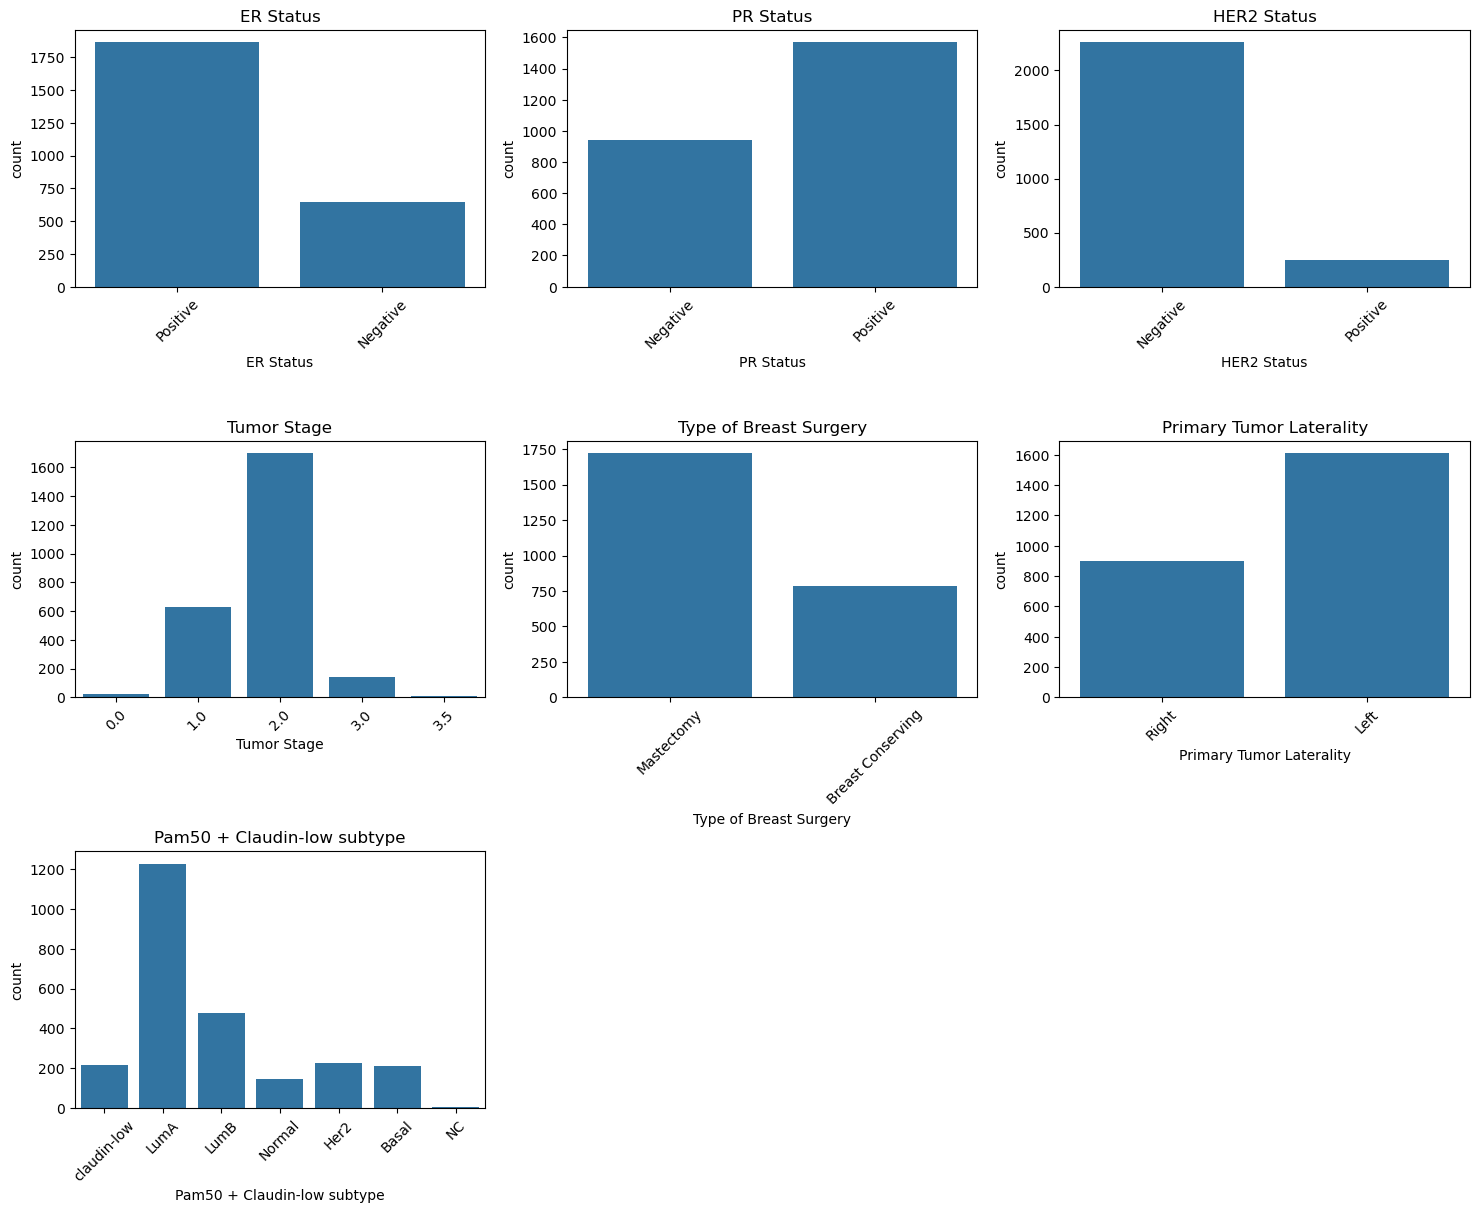

In [76]:
## Shows class imbalance in categorical variables(cat columns only)
cat_cols = [
    "ER Status",
    "PR Status",
    "HER2 Status",
    "Tumor Stage",
    "Type of Breast Surgery",
    "Primary Tumor Laterality",
    "Pam50 + Claudin-low subtype"
]

fig, axes = plt.subplots(3, 3, figsize=(18,14))
plt.subplots_adjust(hspace=0.6)

for i, col in enumerate(cat_cols):
    r, c = divmod(i, 3)
    sns.countplot(x=col, data=df, ax=axes[r,c])
    axes[r,c].set_title(col)
    axes[r,c].tick_params(axis='x', rotation=45)

# Removes empty plots
for j in range(len(cat_cols), 9):
    r, c = divmod(j, 3)
    axes[r, c].axis('off')

plt.show()



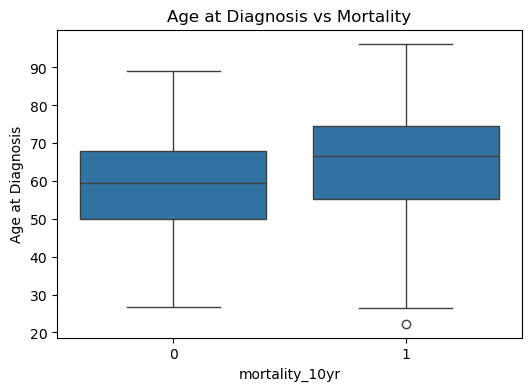

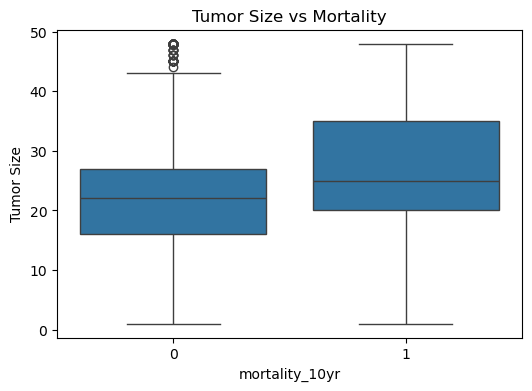

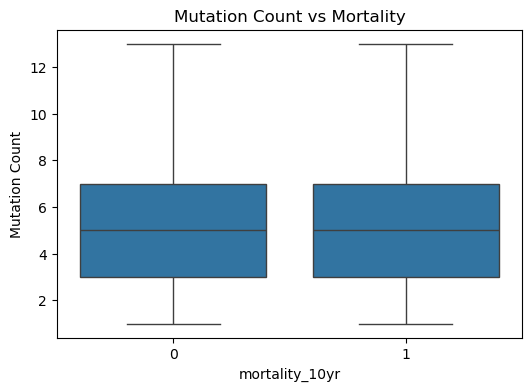

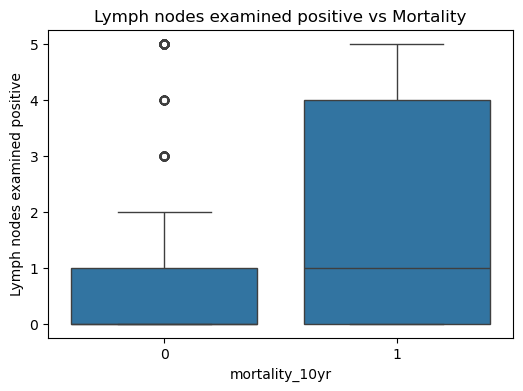

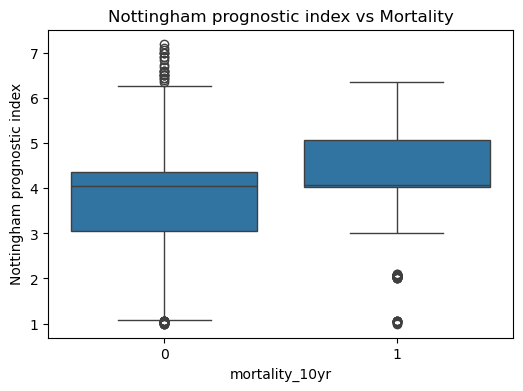

In [77]:
## boxplot to See which numeric features differ between alive vs dead.
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="mortality_10yr", y=col, data=df)
    plt.title(f"{col} vs Mortality")
    plt.show()


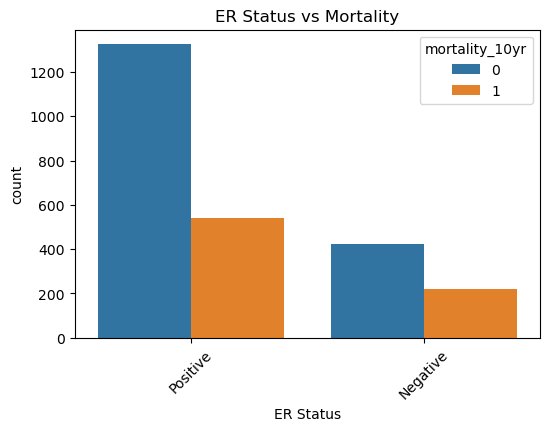

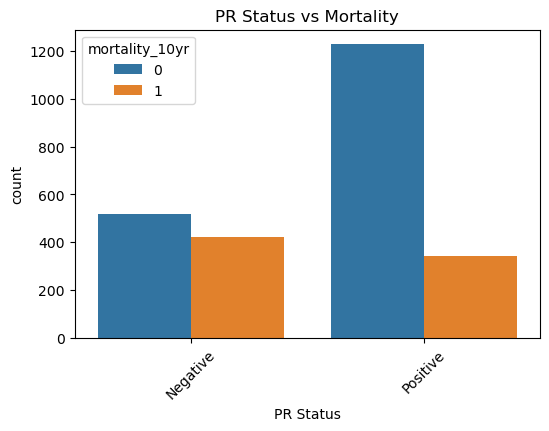

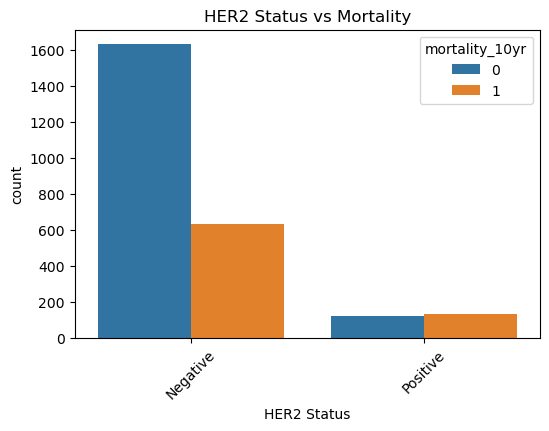

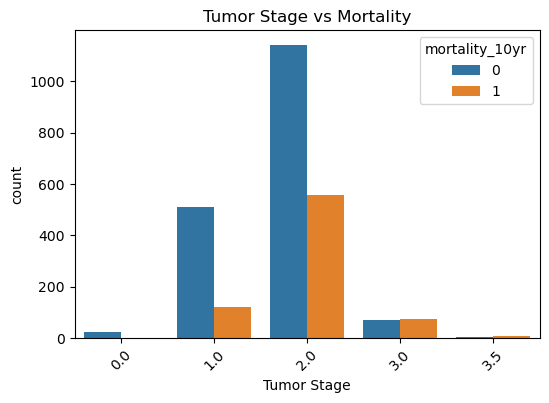

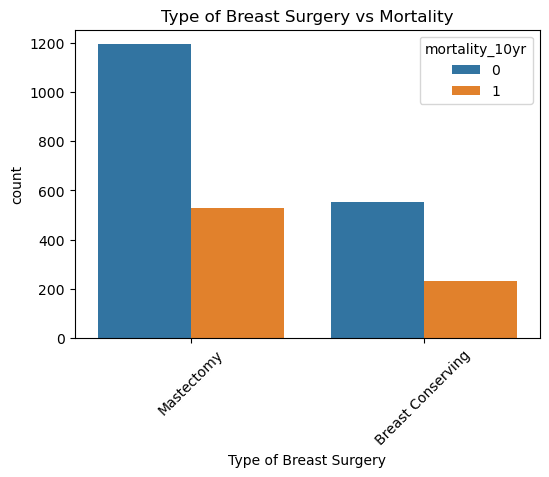

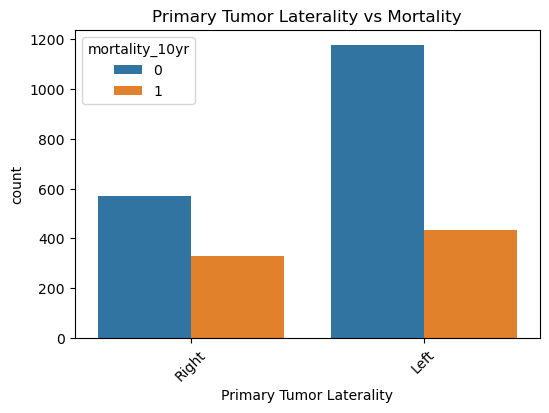

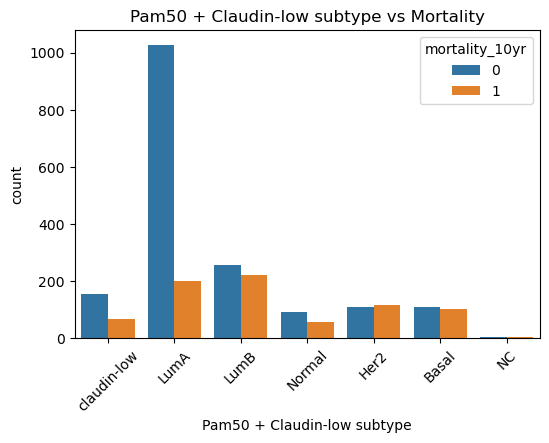

In [78]:
## Identifying  important categorical predictors
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue="mortality_10yr", data=df)
    plt.title(f"{col} vs Mortality")
    plt.xticks(rotation=45)
    plt.show()


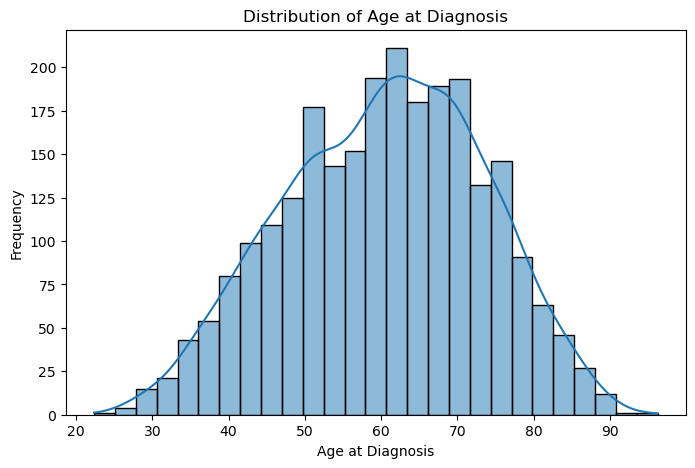

In [79]:
# checking the skewness  useing the histplot 
col = "Age at Diagnosis"

plt.figure(figsize=(8,5))
sns.histplot(df[col], kde=True)
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()


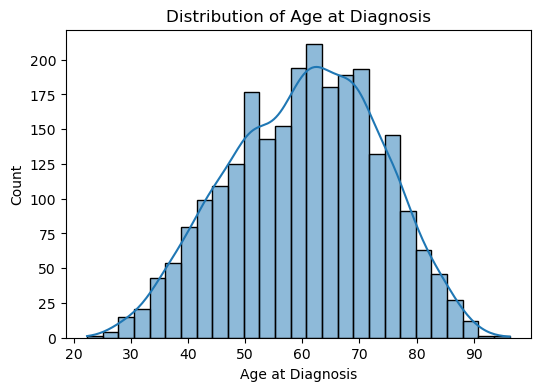

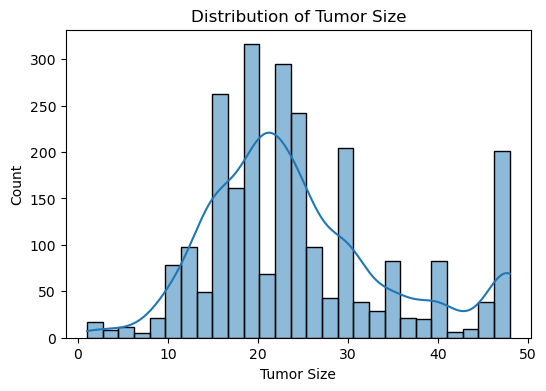

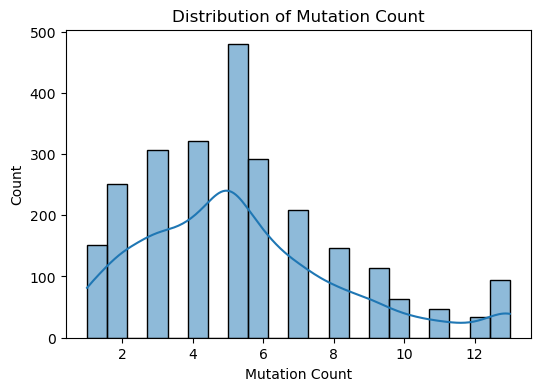

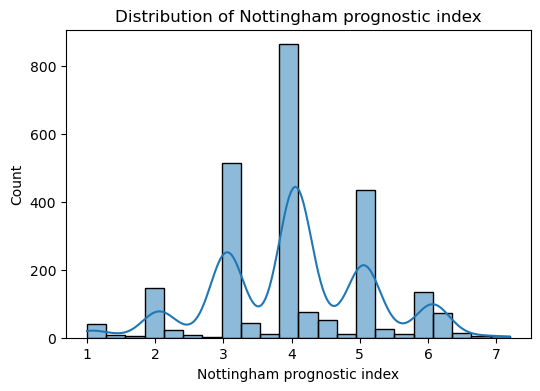

In [80]:
num_cols = [
    "Age at Diagnosis",
    "Tumor Size",
    "Mutation Count",
    "Nottingham prognostic index"
]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


In [81]:
df[num_cols].skew()

Age at Diagnosis              -0.156041
Tumor Size                     0.734521
Mutation Count                 0.798812
Nottingham prognostic index   -0.079571
dtype: float64

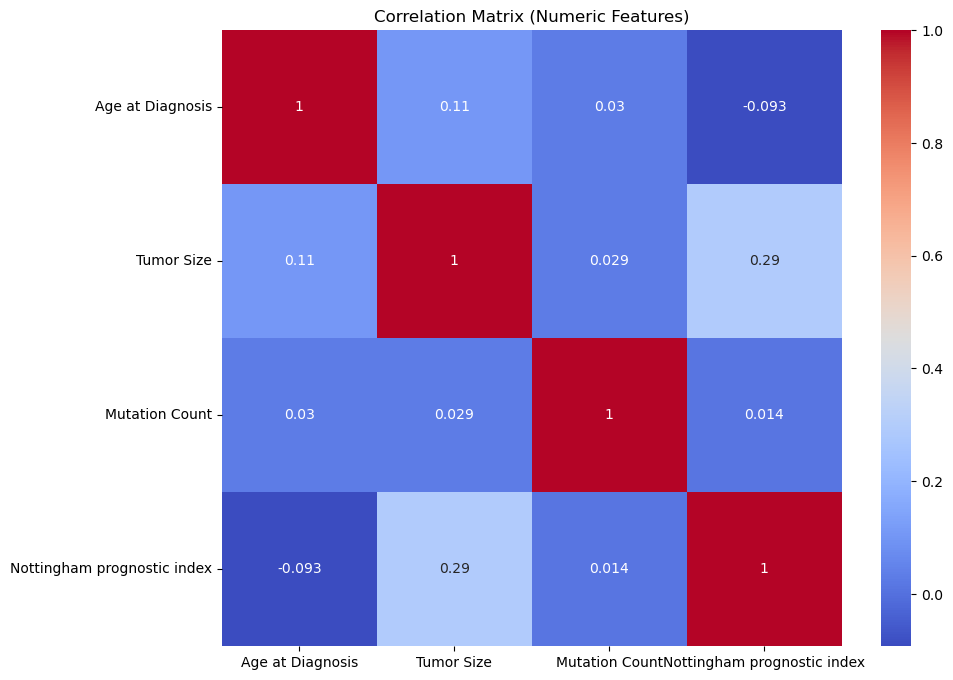

In [82]:
## visulizing the correlation with the target variable useing heatmap
plt.figure(figsize=(10,8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix (Numeric Features)")
plt.show()


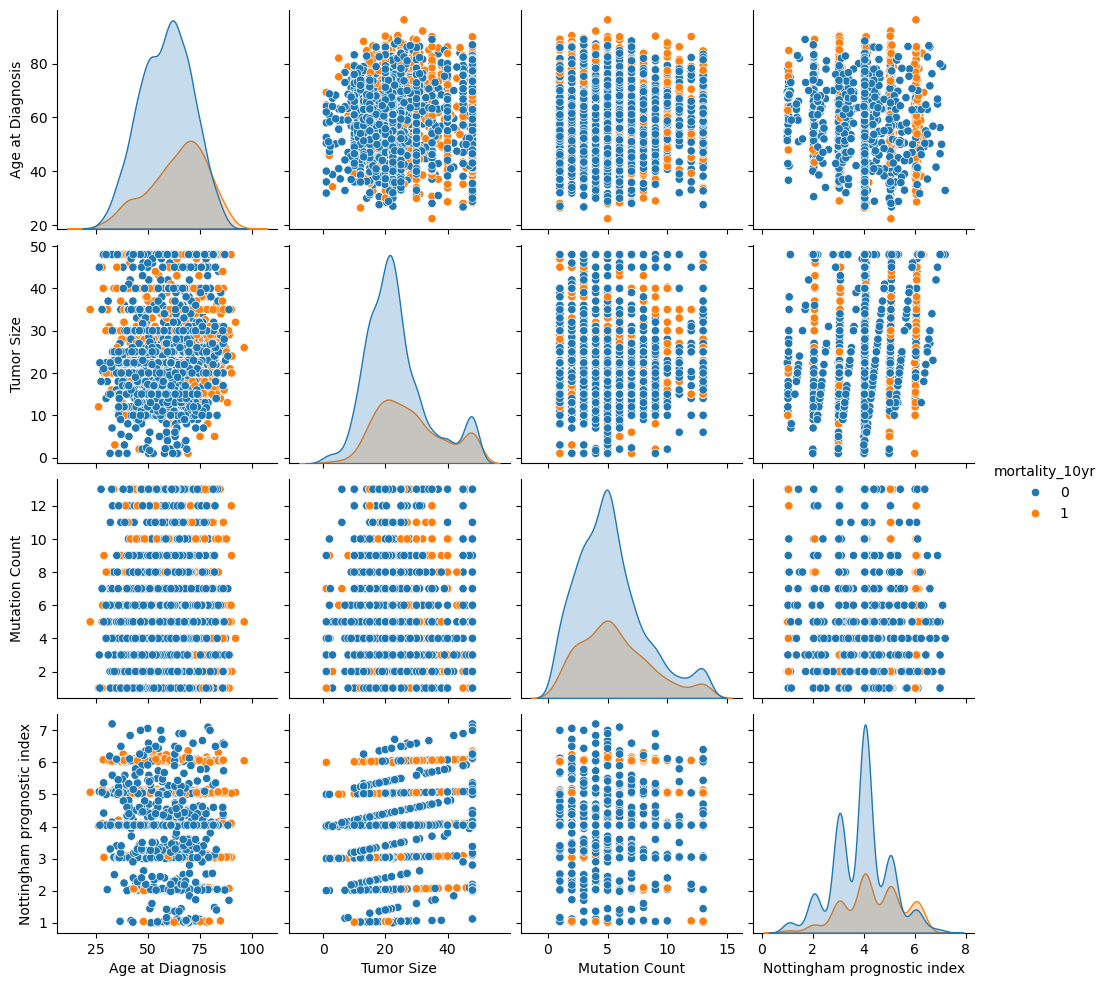

In [83]:
## Visualizing a interaction patterns useing a pair plot
sns.pairplot(df[num_cols + ["mortality_10yr"]], hue="mortality_10yr")
plt.show()


## Kaplan–Meier is used because:

Patients enter and leave at different times

Some patients are still alive

Normal accuracy or mean can’t handle this

Kaplan–Meier curve shows the probability that a patient survives beyond a given time, while correctly handling patients who are still alive.

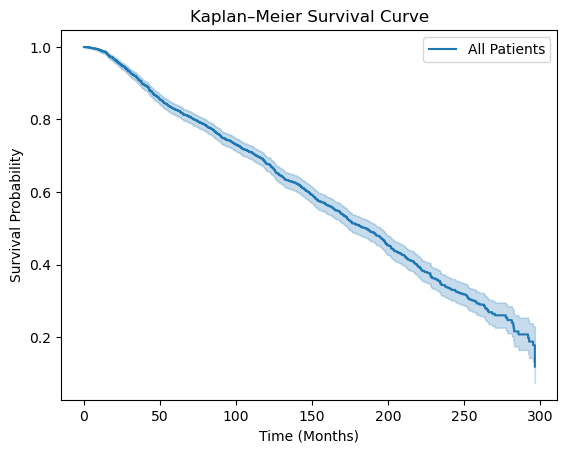

In [84]:
#Kaplan–Meier does NOT predict, it DESCRIBES survival over time.
#As time goes on, what fraction of patients are still alive
from lifelines import KaplanMeierFitter    ## for calculateing a survival we use kaplanmeierfitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()  # This object will: Watch when deaths happen Calculate survival probability step by step

kmf.fit(
    durations=df_survival["Overall Survival (Months)"],
    event_observed=df_survival["event"],
    label="All Patients"
)

kmf.plot_survival_function()
plt.title("Kaplan–Meier Survival Curve")
plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")
plt.show()


In [85]:
df_survival["Chemotherapy"].value_counts() #Chemotherapy received=yes // Chemotherapy not received=NO

Chemotherapy
No     2097
Yes     412
Name: count, dtype: int64

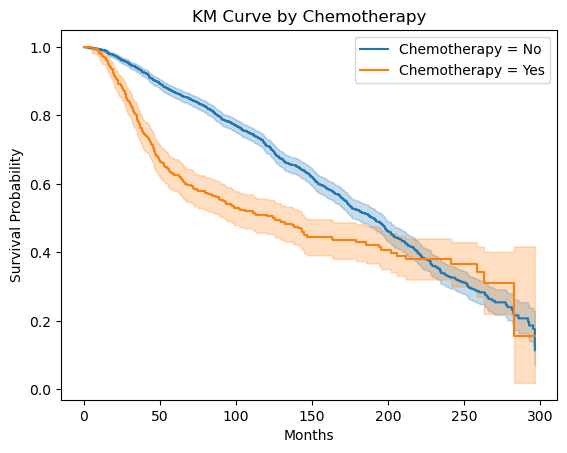

In [86]:
#drawing two survival curves to compare patients who received chemotherapy vs those who did not.
# chemotherapy is a cancer treatment 
fig, ax = plt.subplots()

for grp in df_survival["Chemotherapy"].dropna().unique():
    mask = df_survival["Chemotherapy"] == grp
    kmf.fit(
        df_survival.loc[mask, "Overall Survival (Months)"],
        df_survival.loc[mask, "event"],
        label=f"Chemotherapy = {grp}"
    )
    kmf.plot(ax=ax)

plt.title("KM Curve by Chemotherapy")
plt.xlabel("Months")
plt.ylabel("Survival Probability")
plt.show()


In [87]:
cox_df = df_survival[[
    "Overall Survival (Months)",
    "event",
    "Age at Diagnosis",
    "Tumor Size",
    "Lymph nodes examined positive",
    "Chemotherapy",
    "ER Status"
]].dropna()


In [88]:
cox_df = pd.get_dummies(cox_df, drop_first=True) ## encodeing 


In [89]:
#Cox model answers:Which factors increase or decrease the risk of death over time
# This trains a Cox regression survival model that estimates hazard ratios.

# Hazard Ratio (HR) = exp(coef)

# HR > 1 → increases risk of death

# HR < 1 → decreases risk (protective)

# HR = 1 → no effect
from lifelines import CoxPHFitter

cph = CoxPHFitter()

cph.fit(
    cox_df,
    duration_col="Overall Survival (Months)",
    event_col="event"
)

cph.print_summary()


<lifelines.CoxPHFitter: fitted with 2509 total observations, 1366 right-censored observations>
             duration col = 'Overall Survival (Months)'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 2509
number of events observed = 1143
   partial log-likelihood = -7848.89
         time fit was run = 2026-02-08 03:23:37 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
Age at Diagnosis               0.05      1.05      0.00            0.04            0.05                1.04                1.05
Tumor Size                     0.01      1.01      0.00            0.01            0.02                1.01                1.02
Lymph nodes examined positive  0.14      1.15      0.02            0.10            0.17                1.11                1.19
Chemotherapy_Yes               0.72      2.05      0.10            0.53            0.91                1.69                2.48
ER Status_Positive            -0.08      0.92      0.08           -0.24            0.07                0.79                1.07

                               cmp to     z      p  -log2(p)
covariate                                                   
Age at Diagnosis                 0.00 15.67 <0.005    181.40
Tumor Size                       0.00  5.27 <0.005     22.81
Lymph nodes examined positive    0.00  7.93 <0.005     48.66
Chemotherapy_Yes                 0.00  7.36 <0.005     42.33
ER Status_Positive               0.00 -1.07   0.29      1.81
---
Concordance = 0.68
Partial AIC = 15707.77
log-likelihood ratio test = 479.28 on 5 df
-log2(p) of ll-ratio test = 334.27

Concordance = 0.68
This is similar to AUC for survival models.
0.5 → random
0.6–0.7 → acceptable
0.7+ → strong

Age at Diagnosis
coef = 0.05
HR = exp(coef) = 1.05
p < 0.005
Each additional year of age → 5% higher risk of death
Statistically significant
Older patients have worse survival

Tumor Size
HR = 1.01
p < 0.005
Larger tumors slightly increase mortality risk
Every unit increase in size → ~1% higher hazard
Bigger tumors → worse prognosis

Lymph Nodes Examined Positive
HR = 1.15
p < 0.005
Each additional positive lymph node → 15% higher risk
Strong prognostic factor

Chemotherapy_Yes
HR = 2.05
p < 0.005
This does NOT mean chemo causes death.
Patients who received chemotherapy already had more aggressive disease, so their baseline risk was higher.
This is called confounding by indication.
Chemotherapy appears associated with higher hazard because it is mainly given to high-risk patients.

ER Status Positive
HR = 0.92
p = 0.29 (NOT significant)
Slight protective trend
But not statistically significant
So we cannot conclude ER positivity independently affects survival in this model.

Conclusion:
I trained a Cox proportional hazards model using overall survival time and event status. Age, tumor size, and number of positive lymph nodes significantly increased hazard of death. Chemotherapy was also associated with higher hazard due to confounding by indication, as high-risk patients are more likely to receive it. The model achieved a concordance of 0.68, indicating moderate discriminative ability.

## One hot encodeing 

In [90]:
## one hot encodeing converting a categorical data to a numeric
df=pd.get_dummies(df,drop_first=True)

In [91]:
##Separate target and features
y = df["mortality_10yr"]
X = df.drop(columns=["mortality_10yr"])

In [92]:
## Removeing a leakage columns here we  must drop survival-related columns that directly define the target.
leakage_cols = [
    "Overall Survival (Months)",
    "Overall Survival Status_Living",
    "Relapse Free Status (Months)",
    "Relapse Free Status_Recurred",
    "Patient's Vital Status_Living",
    "Patient's Vital Status_Died of Other Causes",
    "Radio Therapy_Yes", "Hormone Therapy_Yes"
]


X = X.drop(columns=[col for col in leakage_cols if col in X.columns])  ## here we dropeing this columns because If these stay:Model learns the answer directly Accuracy becomes meaningless


In [93]:
Xfea=X.columns.tolist()

In [94]:
Xfea

['Age at Diagnosis',
 'Cohort',
 'Neoplasm Histologic Grade',
 'Lymph nodes examined positive',
 'Mutation Count',
 'Nottingham prognostic index',
 'Tumor Size',
 'Tumor Stage',
 'Type of Breast Surgery_Mastectomy',
 'Cancer Type_Breast Sarcoma',
 'Cancer Type Detailed_Breast Angiosarcoma',
 'Cancer Type Detailed_Breast Invasive Ductal Carcinoma',
 'Cancer Type Detailed_Breast Invasive Lobular Carcinoma',
 'Cancer Type Detailed_Breast Invasive Mixed Mucinous Carcinoma',
 'Cancer Type Detailed_Breast Mixed Ductal and Lobular Carcinoma',
 'Cancer Type Detailed_Invasive Breast Carcinoma',
 'Cancer Type Detailed_Metaplastic Breast Cancer',
 'Cellularity_Low',
 'Cellularity_Moderate',
 'Chemotherapy_Yes',
 'Pam50 + Claudin-low subtype_Her2',
 'Pam50 + Claudin-low subtype_LumA',
 'Pam50 + Claudin-low subtype_LumB',
 'Pam50 + Claudin-low subtype_NC',
 'Pam50 + Claudin-low subtype_Normal',
 'Pam50 + Claudin-low subtype_claudin-low',
 'ER status measured by IHC_Positve',
 'ER Status_Positive',


In [95]:
X=X.drop( "mortality_10yr", axis=True,errors="ignore")
y = df["mortality_10yr"]  ## Series 1d form

In [96]:
print(y.value_counts());

mortality_10yr
0    1749
1     760
Name: count, dtype: int64


## Splitting the dataset into train and test 

In [97]:
from sklearn.model_selection import train_test_split  ### Spliting the dataset into training and testing 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [98]:

## We use StandardScaler so that all numerical features are on the same scale, otherwise some models get biased toward features with large values.
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)     ### We use transform() on test data because the scaler must NOT learn anything from the test set.


## Building a MachineLearning Models

In [99]:
from sklearn.linear_model import LogisticRegression
## Here I increased max_iter to ensure convergence because the dataset is high-dimensional after encoding, and logistic regression may require more iterations to optimize the loss.”
model = LogisticRegression(max_iter=1000, class_weight="balanced")  ## Logistic Regression learns using an iterative optimization algorithm ## maximum number of steps the algorithm is allowed to take to learn
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [100]:
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)
y_prob = model.predict_proba(X_test)[:, 1]  # I used predict_proba to obtain class-1 probabilities, which represent the predicted 10-year mortality risk and are required for ROC-AUC evaluation


In [101]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report,confusion_matrix

print(f"Accuracy on the test data: {accuracy_score(y_test, y_pred_test)*100:.2f}%")
print(f"Accuracy on the train data: {accuracy_score(y_train, y_pred_train)*100:.2f}%")
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred_test))


Accuracy on the test data: 72.71%
Accuracy on the train data: 73.29%
ROC-AUC: 0.8012781954887218
              precision    recall  f1-score   support

           0       0.85      0.74      0.79       350
           1       0.54      0.70      0.61       152

    accuracy                           0.73       502
   macro avg       0.69      0.72      0.70       502
weighted avg       0.75      0.73      0.74       502



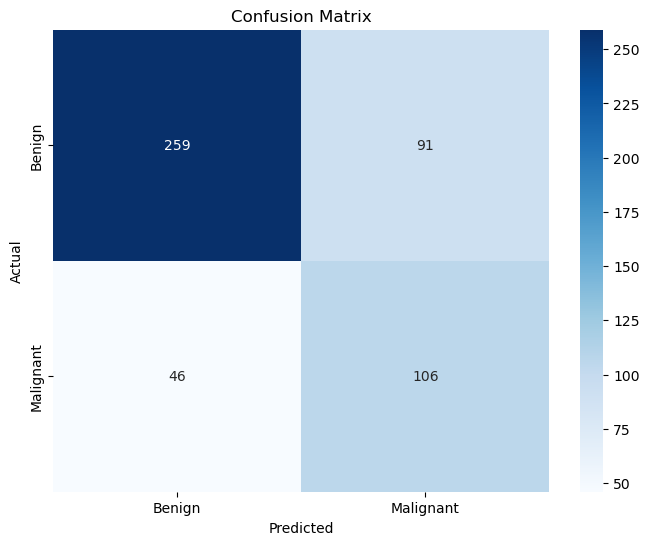

In [102]:
## confusion matrix heatmap
logistic_confusion = confusion_matrix(y_test, y_pred_test )

plt.figure(figsize=(8, 6))
sns.heatmap(logistic_confusion, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

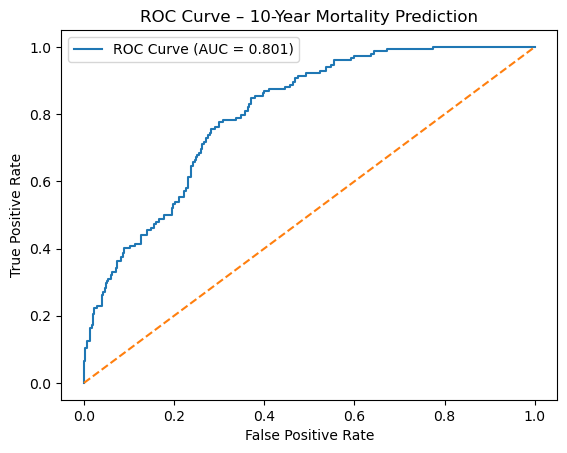

In [103]:
## Roc and Auc curve 
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – 10-Year Mortality Prediction")
plt.legend()
plt.show()



The model achieved an ROC–AUC score of 0.801, indicating good discriminative ability in distinguishing between positive and negative classes

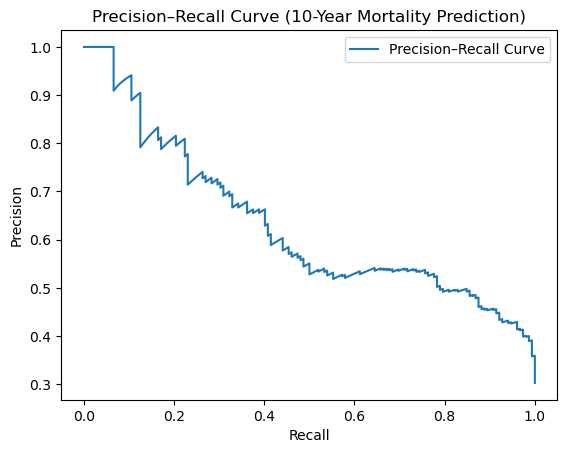

In [104]:
## precision and recall curve for 10 years 
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision, label="Precision–Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (10-Year Mortality Prediction)")
plt.legend()
plt.show()


The Precision–Recall curve indicates that the model maintains a good balance between precision and recall across different thresholds, demonstrating reliable performance in predicting 10-year mortality risk.

In [105]:
## Building an svm model
from sklearn.svm import SVC
svm_model = SVC(
    kernel="rbf",        # non-linear (best default)
    C=1.0,               # regularization strength
    probability=True,     # needed for predict_proba
    class_weight="balanced", 
    random_state=42
)
svm_model.fit(X_train, y_train)


SVC(class_weight='balanced', probability=True, random_state=42)

In [106]:
y_pred_svm = svm_model.predict(X_test)
y_pred_svm_train = svm_model.predict(X_train)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]
print("SVM test Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM training Accuracy:", accuracy_score(y_train, y_pred_svm_train))
print("SVM ROC-AUC:", roc_auc_score(y_test, y_prob_svm))
print(classification_report(y_test, y_pred_svm))

SVM test Accuracy: 0.703187250996016
SVM training Accuracy: 0.7777777777777778
SVM ROC-AUC: 0.7961748120300752
              precision    recall  f1-score   support

           0       0.86      0.69      0.76       350
           1       0.51      0.73      0.60       152

    accuracy                           0.70       502
   macro avg       0.68      0.71      0.68       502
weighted avg       0.75      0.70      0.71       502



As compare to the logistic regression model this svm model drops the test accuracy by 2% and and training accuracy is increased by 7%

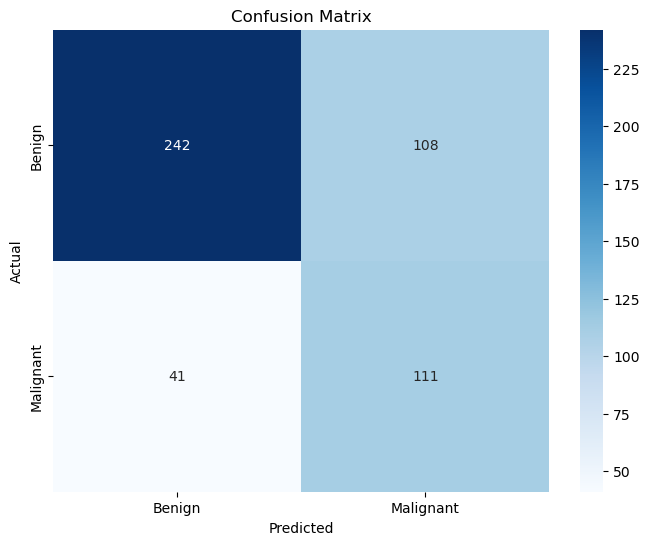

In [108]:
svm_confusion = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(svm_confusion, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [109]:
## Decision Tree model was built and optimized to achieve higher prediction accuracy
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    class_weight="balanced"
)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                       min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [110]:
y_pred_dt = dt_model.predict(X_test)
y_pred_dt_train = dt_model.predict(X_train)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

print("Decision Tree Accuracy on the test dataset:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Accuracy on the train dataset:", accuracy_score(y_train, y_pred_dt_train))
print("Decision Tree ROC-AUC:", roc_auc_score(y_test, y_prob_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy on the test dataset: 0.7051792828685259
Decision Tree Accuracy on the train dataset: 0.7453911310413552
Decision Tree ROC-AUC: 0.7942951127819549
              precision    recall  f1-score   support

           0       0.85      0.71      0.77       350
           1       0.51      0.70      0.59       152

    accuracy                           0.71       502
   macro avg       0.68      0.70      0.68       502
weighted avg       0.74      0.71      0.72       502



In [111]:
## finding the best thresholds value 
import numpy as np
from sklearn.metrics import f1_score

y_prob =dt_model.predict_proba(X_test)[:,1]

thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores = []

for t in thresholds:
    preds = (y_prob_dt >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds))

best_threshold = thresholds[np.argmax(f1_scores)]
best_threshold


np.float64(0.36000000000000004)

In [112]:
## checking how dt model is predicting 
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

y_prob_dt.min(), y_prob.max()

(np.float64(0.0), np.float64(0.952682063155437))

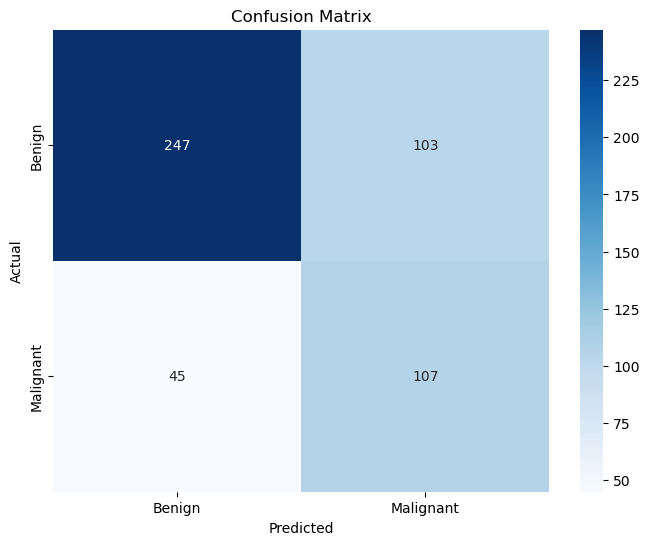

In [113]:
dt_confusion = confusion_matrix(y_test, y_pred_dt )

plt.figure(figsize=(8, 6))
sns.heatmap(dt_confusion, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [155]:
## Seeing a feature importance 
importances=dt_model.feature_importances_

In [157]:
## converting features and importance to the dataframe 
import pandas as pd

feat_imp = pd.DataFrame({
    "Feature": Xfea,
    "Importance": dt_model.feature_importances_
})

feat_imp = feat_imp.sort_values(by="Importance", ascending=False)
feat_imp.head(20)

,Feature,Importance
0,Age at Diagnosis,0.305946
21,Pam50 + Claudin-low subtype_LumA,0.280948
1,Cohort,0.117299
5,Nottingham prognostic index,0.114134
48,Integrative Cluster_8,0.062173
3,Lymph nodes examined positive,0.032328
6,Tumor Size,0.023094
2,Neoplasm Histologic Grade,0.019418
8,Type of Breast Surgery_Mastectomy,0.015972
59,3-Gene classifier subtype_ER+/HER2- Low Prolif,0.013741


<Axes: >

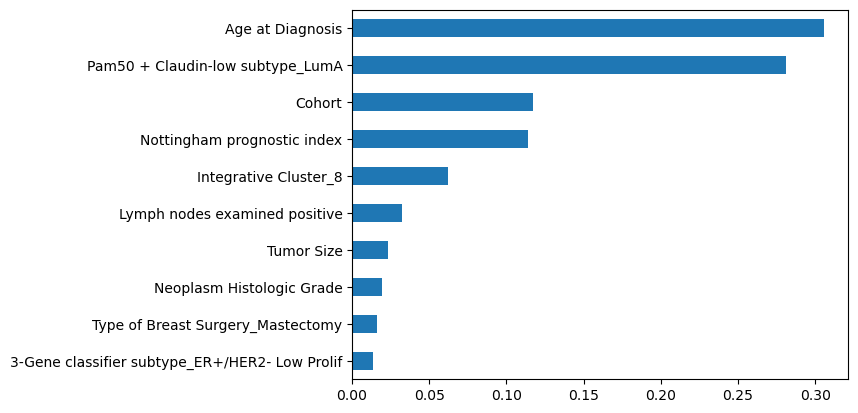

In [158]:
weights = pd.Series(importances,
                 index=X.columns.values)
weights.sort_values()[-10:].plot(kind = 'barh')

In [116]:
## Takeing top features 
top_features = feat_imp[feat_imp["Importance"] > 0]["Feature"].tolist()
top_features

['Age at Diagnosis',
 'Pam50 + Claudin-low subtype_LumA',
 'Cohort',
 'Nottingham prognostic index',
 'Integrative Cluster_8',
 'Lymph nodes examined positive',
 'Tumor Size',
 'Neoplasm Histologic Grade',
 'Type of Breast Surgery_Mastectomy',
 '3-Gene classifier subtype_ER+/HER2- Low Prolif',
 'Mutation Count',
 'Cancer Type Detailed_Breast Invasive Ductal Carcinoma']

## Retraining a decision tree Model useing only a top important features 

In [117]:
## retraining the model on the top_features
Re_train_X = df[top_features]
Re_train_y = df["mortality_10yr"]

In [118]:
## seeing a shape of the X and y variable 
print(Re_train_X.shape)
print(Re_train_y.shape)

(2509, 12)
(2509,)


In [119]:
from sklearn.model_selection import train_test_split  ### Spliting the dataset into training and testing 
X_train, X_test, y_train, y_test = train_test_split(
    Re_train_X, Re_train_y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [120]:
## Applying a standard scaler 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [121]:
## Now we retraining a decision tree model
from sklearn.tree import DecisionTreeClassifier

re_train_dt_model = DecisionTreeClassifier(
    max_depth=6,
    class_weight="balanced",
    random_state=42
)

re_train_dt_model.fit(X_train_scaled, y_train)


DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=42)

In [122]:
## Finally we are evaluating a retrained model
from sklearn.metrics import accuracy_score, roc_auc_score

y_pred_test = re_train_dt_model.predict(X_test_scaled)
y_pred_train = re_train_dt_model.predict(X_train_scaled)
y_prob = re_train_dt_model.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("Accuracy:", accuracy_score(y_train, y_pred_train))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Accuracy: 0.6533864541832669
Accuracy: 0.7548579970104634
ROC-AUC: 0.7494736842105263


Initially a Decision Tree achieved 70% test accuracy. Feature importance-based selection was performed, which slightly reduced accuracy to 65% but improved interpretability. Therefore, the full-feature model was selected as the final model.

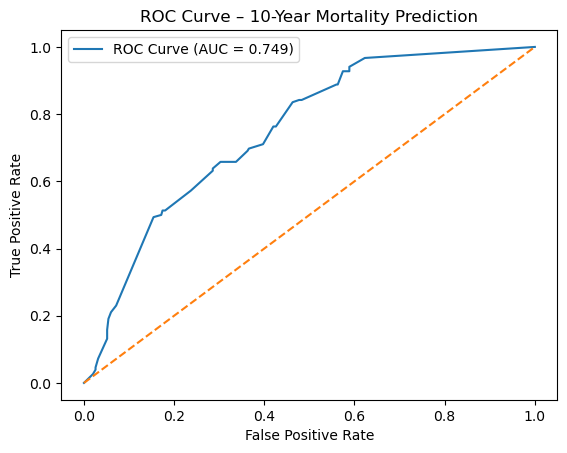

In [123]:
## Roc and Auc curve 
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – 10-Year Mortality Prediction")
plt.legend()
plt.show()


The ROC curve shows that the model achieves an AUC of 0.749, indicating fair to good discriminative ability for 10-year mortality prediction.

In [74]:
# import joblib

# joblib.dump(dt_model, "mortality_model.pkl")
# joblib.dump(scaler, "scaler.pkl")


In [75]:
# import joblib
# joblib.dump(top_features, "features.pkl")

In [126]:
## Using an ensemble technique, Here i applied the Random Forest classifier to improve predictive accuracy and model robustness.
from sklearn.ensemble import RandomForestClassifier

In [127]:
rfc=RandomForestClassifier(class_weight="balanced",
    max_depth=6,
    random_state=42)

In [128]:
rfc.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=6, random_state=42)

In [129]:
y_predict_test_rfc=rfc.predict(X_test)
y_predict_train_rfc=rfc.predict(X_train)
y_prob_rfc = rfc.predict_proba(X_test)[:,1]




In [130]:
print(f"{accuracy_score(y_test,y_predict_test_rfc)*100:.2f}%")
print(f"{accuracy_score(y_train,y_predict_train_rfc)*100:.2f}%")
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rfc))

71.91%
77.73%
ROC-AUC: 0.8178947368421055


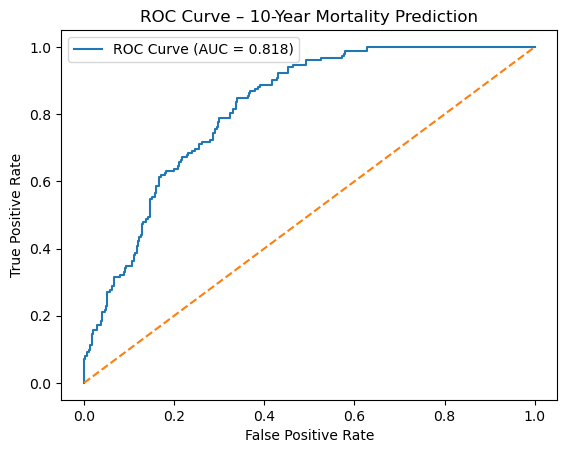

In [131]:
## Roc and Auc curve 
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rfc)
roc_auc = roc_auc_score(y_test, y_prob_rfc)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – 10-Year Mortality Prediction")
plt.legend()
plt.show()


The model showed slight overfitting with 77% training accuracy and 71% test accuracy; therefore, GridSearchCV was applied to tune hyperparameters and improve generalization.

In [138]:
param_grid = {
    "n_estimators": [200, 300, 400],
    "max_depth": [4, 6, 8, 10],
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf": [2, 5, 10],
   
}

In [139]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(
    estimator=rfc,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)


Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              max_depth=6, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [4, 6, 8, 10],
                         'min_samples_leaf': [2, 5, 10],
                         'min_samples_split': [5, 10, 20],
                         'n_estimators': [200, 300, 400]},
             scoring='roc_auc', verbose=2)

In [140]:
print("Best Parameters:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)


Best Parameters: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 200}
Best CV ROC-AUC: 0.8034570184528119


In [145]:
# The Random Forest classifier was re-trained using the optimal hyperparameters identified through GridSearchCV to achieve a more robust and generalized model
rfc_best_params= RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, min_samples_split=5,
                       n_estimators=200, random_state=42)

In [146]:
rfc_best_params.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, min_samples_split=5,
                       n_estimators=200, random_state=42)

In [147]:
rfc_best_params_test=rfc_best_params.predict(X_test)
rfc_best_params_train=rfc_best_params.predict(X_train)
print(f"{accuracy_score(rfc_best_params_test,y_test)*100:.2f}%")
print(f"{accuracy_score(rfc_best_params_train,y_train)*100:.2f}%")

73.31%
84.70%


After hyperparameter tuning, the Random Forest model achieved 73.31% test accuracy and 84.70% training accuracy, showing improved predictive performance.

In [150]:
# import joblib

# joblib.dump(dt_model, "mortality_model.pkl")
# joblib.dump(scaler, "scaler.pkl")
# features=X.columns.tolist()
# joblib.dump(features, "features.pkl")